In [1]:
import os
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import face_recognition

PROJECT_ROOT = Path("../").resolve()

AUTHORIZED_DIR = PROJECT_ROOT / "data" / "authorized"
TEST_AUTH_DIR = PROJECT_ROOT / "data" / "test" / "authorized"
TEST_UNAUTH_DIR = PROJECT_ROOT / "data" / "test" / "unauthorized"

print("Project root:", PROJECT_ROOT)
print("Authorized dir exists:", AUTHORIZED_DIR.exists())
print("Test authorized dir exists:", TEST_AUTH_DIR.exists())
print("Test unauthorized dir exists:", TEST_UNAUTH_DIR.exists())

/home/taming3joy/Documents/Coding/CMKL/Year 1/Semester 2/SEC-301/.venv/lib/python3.12/site-packages/face_recognition_models/__init__.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


Project root: /home/taming3joy/Documents/Coding/CMKL/Year 1/Semester 2/SEC-301/face_access_control
Authorized dir exists: True
Test authorized dir exists: True
Test unauthorized dir exists: True


Using image: /home/taming3joy/Documents/Coding/CMKL/Year 1/Semester 2/SEC-301/face_access_control/data/authorized/taming/taming_1.jpg
Image shape: (1280, 720, 3)


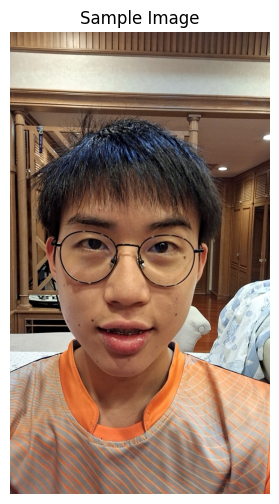

In [52]:
# testing with an image
sample_image_path = AUTHORIZED_DIR / "taming" / "taming_1.jpg"
print("Using image:", sample_image_path)

image = face_recognition.load_image_file(sample_image_path)
print("Image shape:", image.shape)

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.title("Sample Image")
plt.axis("off")
plt.show()

Detected faces: 1
Face locations: [(502, 553, 965, 91)]


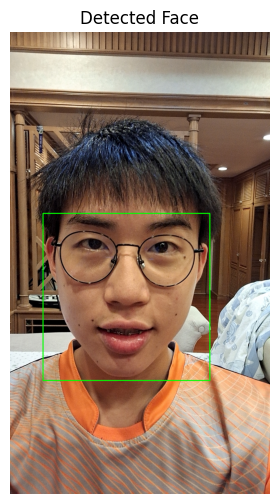

In [53]:
# detecting the face
face_locations = face_recognition.face_locations(image)

print("Detected faces:", len(face_locations))
print("Face locations:", face_locations)

image_bgr = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

for (top, right, bottom, left) in face_locations:
    cv2.rectangle(image_bgr, (left, top), (right, bottom), (0, 255, 0), 2)

image_rgb_boxed = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.imshow(image_rgb_boxed)
plt.title("Detected Face")
plt.axis("off")
plt.show()

In [54]:
# extracting the face embedding
face_encodings = face_recognition.face_encodings(image, face_locations)

print("Number of encodings:", len(face_encodings))

if len(face_encodings) > 0:
    print("Encoding shape:", face_encodings[0].shape)

Number of encodings: 1
Encoding shape: (128,)


In [55]:
# building whitelist of authorized faces of taming & Josh
def build_whitelist(authorized_dir):
    whitelist = {}

    for person_name in os.listdir(authorized_dir):
        person_path = authorized_dir / person_name

        if not person_path.is_dir():
            continue

        embeddings = []

        for file_name in os.listdir(person_path):
            if not file_name.lower().endswith((".jpg", ".jpeg", ".png")):
                continue

            image_path = person_path / file_name
            image = face_recognition.load_image_file(image_path)

            face_locations = face_recognition.face_locations(image)
            face_encodings = face_recognition.face_encodings(image, face_locations)

            if len(face_encodings) == 1:
                embeddings.append(face_encodings[0])
            else:
                print(f"[WARNING] Skipping {image_path}, detected {len(face_encodings)} faces")

        whitelist[person_name] = embeddings
        print(f"{person_name}: {len(embeddings)} valid images")

    return whitelist

whitelist = build_whitelist(AUTHORIZED_DIR)

[WARNING] Skipping /home/taming3joy/Documents/Coding/CMKL/Year 1/Semester 2/SEC-301/face_access_control/data/authorized/josh/josh_6.jpg, detected 0 faces
[WARNING] Skipping /home/taming3joy/Documents/Coding/CMKL/Year 1/Semester 2/SEC-301/face_access_control/data/authorized/josh/josh_12.jpg, detected 0 faces
josh: 17 valid images
[WARNING] Skipping /home/taming3joy/Documents/Coding/CMKL/Year 1/Semester 2/SEC-301/face_access_control/data/authorized/taming/taming_13.jpg, detected 0 faces
[WARNING] Skipping /home/taming3joy/Documents/Coding/CMKL/Year 1/Semester 2/SEC-301/face_access_control/data/authorized/taming/taming_14.jpg, detected 0 faces
[WARNING] Skipping /home/taming3joy/Documents/Coding/CMKL/Year 1/Semester 2/SEC-301/face_access_control/data/authorized/taming/taming_15.jpg, detected 0 faces
taming: 17 valid images


In [56]:
# function to check faces based on whitelist

def recognize_face(image_path, whitelist, threshold=0.60):
    image = face_recognition.load_image_file(image_path)

    face_locations = face_recognition.face_locations(image)
    face_encodings = face_recognition.face_encodings(image, face_locations)

    if len(face_encodings) == 0:
        return "No face detected", None

    if len(face_encodings) > 1:
        return "Multiple faces detected", None

    input_encoding = face_encodings[0]

    best_match = None
    best_distance = float("inf")

    for person_name, embeddings in whitelist.items():
        distances = face_recognition.face_distance(embeddings, input_encoding)

        if len(distances) == 0:
            continue

        min_distance = np.min(distances)

        if min_distance < best_distance:
            best_distance = min_distance
            best_match = person_name

    if best_distance < threshold:
        return best_match, best_distance
    else:
        return "Unknown", best_distance

In [57]:
# testing on an authorized face

test_image = TEST_AUTH_DIR / "taming" / "taming_test_1.jpg"

result, distance = recognize_face(test_image, whitelist)

print("Result:", result)
print("Distance:", distance)

Result: taming
Distance: 0.3337591930867437


In [58]:
# testing on an unauthorized face

unauth_image = TEST_UNAUTH_DIR / "kaggle_unknown_01.jpg"

result, distance = recognize_face(unauth_image, whitelist)

print("Result:", result)
print("Distance:", distance)

Result: Unknown
Distance: 0.6995456773824985


In [59]:
# evaluating embeddings

def evaluate_folder(folder_path, whitelist, true_label=None, threshold=0.60):
    results = []

    for file_name in sorted(os.listdir(folder_path)):
        if not file_name.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        image_path = folder_path / file_name
        predicted_label, distance = recognize_face(image_path, whitelist, threshold=threshold)

        expected_label = "Unknown" if true_label is None else true_label

        face_detected = predicted_label not in ["No face detected", "Multiple faces detected"]

        if face_detected:
            correct_recognition = (predicted_label == expected_label)
        else:
            correct_recognition = None

        results.append({
            "file_name": file_name,
            "expected": expected_label,
            "predicted": predicted_label,
            "distance": distance,
            "face_detected": face_detected,
            "correct_recognition": correct_recognition
        })

    return results

taming_results = evaluate_folder(TEST_AUTH_DIR / "taming", whitelist, true_label="taming")
josh_results = evaluate_folder(TEST_AUTH_DIR / "josh", whitelist, true_label="josh")
unauth_results = evaluate_folder(TEST_UNAUTH_DIR, whitelist, true_label=None)

In [60]:
# analyzing results

def summarize_results(results, title):
    total = len(results)
    detected = sum(r["face_detected"] for r in results)
    not_detected = total - detected

    correct_when_detected = sum(1 for r in results if r["correct_recognition"] is True)

    recognition_accuracy = (correct_when_detected / detected if detected > 0 else 0)

    detection_rate = detected / total if total > 0 else 0

    print(title)
    print(f"Total images: {total}")
    print(f"Detected faces: {detected}")
    print(f"No face detected / multiple faces: {not_detected}")
    print(f"Detection rate: {detection_rate:.2%}")
    print(f"Recognition accuracy (when face detected): {recognition_accuracy:.2%}")

def show_failures(results):
    failures = [r for r in results if not r["correct_recognition"]]
    if not failures:
        print("No failures")
    else:
        for r in failures:
            print(r)
    print()

summarize_results(taming_results, "Taming Test Results")
show_failures(taming_results)

summarize_results(josh_results, "Josh Test Results")
show_failures(josh_results)

summarize_results(unauth_results, "Unauthorized Test Results")
show_failures(unauth_results)

Taming Test Results
Total images: 5
Detected faces: 4
No face detected / multiple faces: 1
Detection rate: 80.00%
Recognition accuracy (when face detected): 100.00%
{'file_name': 'taming_test_3.jpg', 'expected': 'taming', 'predicted': 'Multiple faces detected', 'distance': None, 'face_detected': False, 'correct_recognition': None}

Josh Test Results
Total images: 5
Detected faces: 2
No face detected / multiple faces: 3
Detection rate: 40.00%
Recognition accuracy (when face detected): 100.00%
{'file_name': 'josh_test_2.jpg', 'expected': 'josh', 'predicted': 'Multiple faces detected', 'distance': None, 'face_detected': False, 'correct_recognition': None}
{'file_name': 'josh_test_4.jpg', 'expected': 'josh', 'predicted': 'No face detected', 'distance': None, 'face_detected': False, 'correct_recognition': None}
{'file_name': 'josh_test_5.jpg', 'expected': 'josh', 'predicted': 'Multiple faces detected', 'distance': None, 'face_detected': False, 'correct_recognition': None}

Unauthorized Test